In [1]:
# Set up
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path(".").resolve()
PRE_DIR = DATA_DIR / "pre"
POST_DIR = DATA_DIR / "post"
MANIFEST_PATH = DATA_DIR / "manifest_train.csv"

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110

In [2]:
# Load manifest
df = pd.read_csv(MANIFEST_PATH)
print('Manifest rows:', len(df))
df.head()

Manifest rows: 162787


,building_id,scene_id,split,disaster_type,damage_label,pre_crop_path,post_crop_path,original_bbox,original_crop_width,original_crop_height
0,hurricane-harvey_00000348_b0000,hurricane-harvey_00000348,tier1,hurricane-harvey,no-damage,../data/processed/tier1/pre/hurricane-harvey_0...,../data/processed/tier1/post/hurricane-harvey_...,"(25, 0, 177, 235)",152,235
1,hurricane-harvey_00000348_b0001,hurricane-harvey_00000348,tier1,hurricane-harvey,no-damage,../data/processed/tier1/pre/hurricane-harvey_0...,../data/processed/tier1/post/hurricane-harvey_...,"(150, 0, 302, 244)",152,244
2,hurricane-harvey_00000348_b0002,hurricane-harvey_00000348,tier1,hurricane-harvey,no-damage,../data/processed/tier1/pre/hurricane-harvey_0...,../data/processed/tier1/post/hurricane-harvey_...,"(306, 0, 415, 172)",109,172
3,hurricane-harvey_00000348_b0003,hurricane-harvey_00000348,tier1,hurricane-harvey,no-damage,../data/processed/tier1/pre/hurricane-harvey_0...,../data/processed/tier1/post/hurricane-harvey_...,"(510, 691, 667, 831)",157,140
4,hurricane-harvey_00000348_b0004,hurricane-harvey_00000348,tier1,hurricane-harvey,no-damage,../data/processed/tier1/pre/hurricane-harvey_0...,../data/processed/tier1/post/hurricane-harvey_...,"(526, 583, 718, 679)",192,96


In [3]:
# Check for missing values in the manifest itself
print(df.isnull().sum())

building_id             0
scene_id                0
split                   0
disaster_type           0
damage_label            0
pre_crop_path           0
post_crop_path          0
original_bbox           0
original_crop_width     0
original_crop_height    0
dtype: int64


In [4]:
# Check which crop files actually exist on disk
# Since we're training on post-disaster images only, we only need post files to exist
post_files = set(os.listdir(POST_DIR))

df["post_base"] = df["post_crop_path"].apply(os.path.basename)
df["post_exists"] = df["post_base"].isin(post_files)

print("Post files on disk:", len(post_files))
print("Manifest rows with POST present:", df["post_exists"].sum(), "/", len(df))

Post files on disk: 21244
Manifest rows with POST present: 21244 / 162787


In [5]:
# Filter to only rows where the post file exists
manifest = df[df["post_exists"]].drop(columns=["post_exists"]).reset_index(drop=True)
print("Usable rows:", len(manifest))
manifest["damage_label"].value_counts(dropna=False)

Usable rows: 21244


damage_label
no-damage        15444
minor-damage      1914
major-damage      1814
destroyed         1699
un-classified      373
Name: count, dtype: int64

In [6]:
# Drop un-classified rows (not a real damage category)
manifest = manifest[manifest["damage_label"] != "un-classified"].reset_index(drop=True)
CLASSES = sorted(manifest["damage_label"].unique())
print(CLASSES)
print("Final usable rows:", len(manifest))

['destroyed', 'major-damage', 'minor-damage', 'no-damage']
Final usable rows: 20871


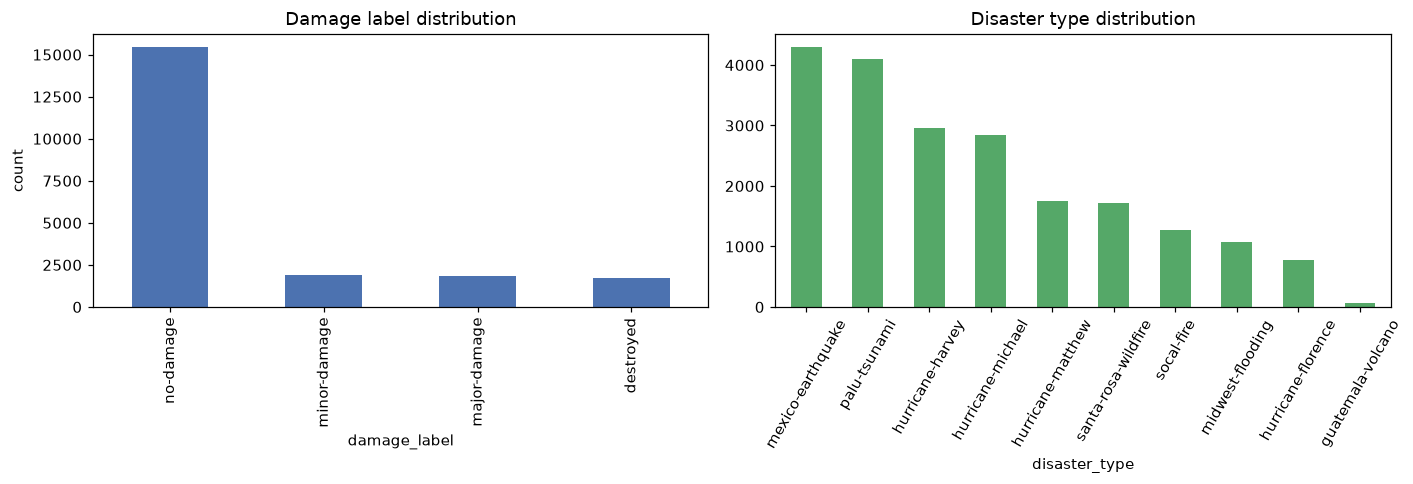

In [7]:
# Class balance charts
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

manifest["damage_label"].value_counts().plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Damage label distribution")
axes[0].set_ylabel("count")

manifest["disaster_type"].value_counts().plot.bar(ax=axes[1], color="#55A868")
axes[1].set_title("Disaster type distribution")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

In [8]:
# Class balance per disaster type
pd.crosstab(manifest["disaster_type"], manifest["damage_label"])

damage_label,destroyed,major-damage,minor-damage,no-damage
disaster_type,,,,
guatemala-volcano,2,0,1,69
hurricane-florence,8,131,14,621
hurricane-harvey,41,1063,329,1523
hurricane-matthew,311,281,849,307
hurricane-michael,93,237,677,1830
mexico-earthquake,1,4,12,4278
midwest-flooding,14,7,15,1046
palu-tsunami,607,71,0,3426
santa-rosa-wildfire,472,14,6,1234


In [9]:
# Leakage-safe scene-based split
# Proportionally split each disaster type into train/val/test sets, so that each set has a similar distribution of disasters
rng_seed = 42

def group_split(scene_meta, train_frac=0.7, val_frac=0.15):
    train_ids, val_ids, test_ids = [], [], []
    for disaster, grp in scene_meta.groupby("disaster_type"):
        scenes = grp["scene_id"].sample(frac=1, random_state=rng_seed).tolist()
        n_train = int(len(scenes) * train_frac)
        n_val = int(len(scenes) * val_frac)
        train_ids += scenes[:n_train]
        val_ids   += scenes[n_train:n_train + n_val]
        test_ids  += scenes[n_train + n_val:]
    return train_ids, val_ids, test_ids

scene_meta = manifest[["scene_id", "disaster_type"]].drop_duplicates()
train_ids, val_ids, test_ids = group_split(scene_meta)
print("Train scenes:", len(train_ids), "Val scenes:", len(val_ids), "Test scenes:", len(test_ids))

Train scenes: 921 Val scenes: 193 Test scenes: 207


In [10]:
# Assign split labels back to the manifest
split_map = {}
split_map.update({s: "train" for s in train_ids})
split_map.update({s: "val" for s in val_ids})
split_map.update({s: "test" for s in test_ids})
manifest["model_split"] = manifest["scene_id"].map(split_map)

assert set(train_ids) & set(val_ids) == set()
assert set(train_ids) & set(test_ids) == set()
assert set(val_ids) & set(test_ids) == set()

print(manifest["model_split"].value_counts())
print()
print(manifest.groupby("model_split")["damage_label"].value_counts(normalize=True).unstack().round(3))

model_split
train    13901
val       3512
test      3458
Name: count, dtype: int64

damage_label  destroyed  major-damage  minor-damage  no-damage
model_split                                                   
test              0.048         0.078         0.079      0.795
train             0.082         0.096         0.103      0.719
val               0.112         0.059         0.060      0.769


In [11]:
# Save the final manifest
manifest.to_csv(DATA_DIR / "manifest_train_split.csv", index=False)
print("Saved:", DATA_DIR / "manifest_train_split.csv")

Saved: /Users/amelia/Downloads/train/manifest_train_split.csv


### Week 2 Summary — Manifest Analysis & Data Split

#### Data availability

- `manifest_train.csv` lists 162,787 building crops (pre + post image pair + damage label per row), but this is a *plan* of what should exist. The CSV has zero missing values, yet only 21,244 post-crop image files actually exist on disk.
- Since the team is training on **post-disaster images only**, filtering only requires the post-crop file to be physically present — this leaves **21,244 usable rows** (13% of the manifest). Cropping/copying for the remaining rows is still incomplete; this can be re-run later if needed.
- Dropped 373 `un-classified` rows (not a real damage category) → **20,871 final usable rows** across 4 classes: `no-damage` (15,444), `minor-damage` (1,914), `major-damage` (1,814), `destroyed` (1,699).

#### Class balance

- Strongly imbalanced: `no-damage` makes up ~74% of the data; `minor-damage`, `major-damage`, and `destroyed` each make up roughly 8–9%.
- Damage severity varies a lot by disaster type — e.g. `palu-tsunami` (607 destroyed) and `santa-rosa-wildfire` (472 destroyed) have high destroyed counts, while `mexico-earthquake` is almost entirely `no-damage` (4,278 of 4,295 rows).
- Will need class weighting (or similar) at training time to prevent the model from just predicting `no-damage` for everything.

#### Train / val / test split

- Split at the **scene level** (`scene_id`), not the row level, to prevent data leakage — buildings from the same disaster scene share lighting, sensor characteristics, and local damage patterns, so splitting by row would let the model "see" a scene during training and get evaluated on it again in test.
- Split per disaster type (70% train / 15% val / 15% test of scenes) so each split keeps a representative mix of disasters. `guatemala-volcano` (only 4 scenes total) landed mostly in train since it's too small to split three ways.
- Result: 921 / 193 / 207 scenes → 13,901 / 3,512 / 3,458 building rows for train / val / test.
- Class balance drifted somewhat across splits — an expected consequence of scene-level splitting, since some scenes are almost entirely destroyed or entirely undamaged:
  - train: 8.2% destroyed, 9.6% major, 10.3% minor, 71.9% no-damage
  - val: 11.2% destroyed, 5.9% major, 6.0% minor, 76.9% no-damage
  - test: 4.8% destroyed, 7.8% major, 7.9% minor, 79.5% no-damage
  Not a bug; just means val/test skew slightly different in severity than train, which is a reasonable generalization stress test.
- Saved as `manifest_train_split.csv` for reuse in Week 3 baseline modeling.